In [1]:
import numpy as np
import matplotlib.pyplot as plt
from codes.Quantum import *
from codes.CSPSA import CSPSA
from ClassicalShadows import EnchancedShadowTomography 

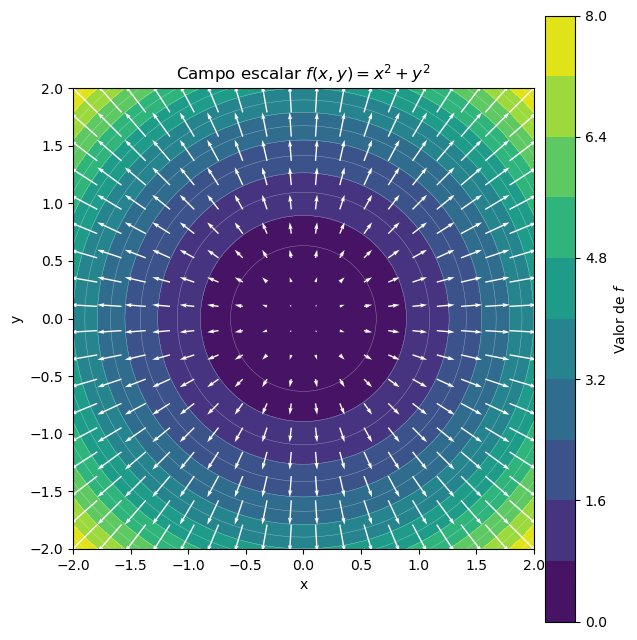

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Campo escalar
def f(x, y):
    return x**2 + y**2

# Gradiente
def grad_f(x, y):
    return 2*x, 2*y

# Malla para el contorno (fina)
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Malla más gruesa para las flechas del gradiente
xq = np.linspace(-2, 2, 20)
yq = np.linspace(-2, 2, 20)
Xq, Yq = np.meshgrid(xq, yq)
Uq, Vq = grad_f(Xq, Yq)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Contorno relleno
contour = ax.contourf(X, Y, Z, levels=10, cmap='viridis')
cbar = fig.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label('Valor de $f$')

# Líneas de contorno finas
ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.3, alpha=0.5)

# Campo de gradiente (flechas normalizadas por dirección)
ax.quiver(Xq, Yq, Uq, Vq, color='white', scale=60, width=0.003)

ax.set_title(r'Campo escalar $f(x,y) = x^2 + y^2$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [2]:
Psi_ab = np.array([ 0, 1, -1, 0 ])/np.sqrt(2)
# Psi_ab = np.array([ 1, 0, 0, 1 ])/np.sqrt(2)
Psi = triple_kron( Psi_ab, Psi_ab, Psi_ab )
Psi2 = Psi.copy()
Psi = Psi.reshape(6*[2]).transpose([5,0,2,1,4,3]).flatten() 
Rho = np.outer( Psi, Psi.conj() )
Rho[:8,:8]

array([[ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [ 0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.   ],
       [-0.   , -0.   ,  0.   ,  0.   , -0.   , -0.   ,  0.   ,  0.125]])

$ Z \rightarrow U = Z(Z^\dagger Z)^{-1/2} $

$U^\dagger U = (Z^\dagger Z)^{-1/2} Z^\dagger Z(Z^\dagger Z)^{-1/2} =  (Z^\dagger Z)^{-1} Z^\dagger Z$ = I

In [3]:
from scipy.linalg import sqrtm 
from scipy.linalg import inv 

In [2]:
def complex2unitary( Z ):

    if Z.ndim == 3:
        for k, z in enumerate(Z):
            Z[k] = z @ inv( sqrtm( z.T.conj()@z ) )
    else:
        Z = Z @ inv( sqrtm( Z.T.conj()@Z ) )

    return Z 

def random_unitary( dim, num=1 ):
    Z = np.random.randn( num, dim, dim ) \
        + 1j*np.random.randn( num, dim, dim )
    return complex2unitary( Z ).squeeze()

In [5]:
enhanced_shadows = EnchancedShadowTomography( 6, 100000 )
enhanced_shadows.train_shadows( Rho )


In [6]:
Rho_hat = enhanced_shadows.estimate_density_matrix()
np.trace( Rho@Rho_hat )

np.complex128(0.9433306335793945+8.673617379884035e-19j)

In [7]:
enhanced_shadows.enhance_shadow( Rho_hat )

In [8]:
def out_fun( Z, Rho=Rho ):

    Z  = np.array(Z)

    Z = complex2unitary( Z )

    Measures = triple_kron( Z[0], Z[1], Z[2] ) 

    # probs = []
    # for j in range( 2**6 ):
    #     probs.append( shadows.estimate_fidelity( Measures[:,j] ) ) 
    # # probs = proyectar_al_simplex( probs )
    # probs = np.array(probs).reshape(6*[2]) 

    probs  = np.sum( Measures.conj() * ( Rho @ Measures ), 
                        axis=0 ).reshape(6*[2]).real 

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1] * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )
    return inequality

In [9]:
def obj_fun( Z, enhanced_shadows=enhanced_shadows ):

    Z  = np.array(Z)

    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]

    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )

    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )

    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )

    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)

    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )

    return inequality 


def obj_fun_enhanced( Z, enhanced_shadows=enhanced_shadows ):

    Z  = np.array(Z)

    Z = complex2unitary( Z )
    Z0 = Z[0]
    Z1 = Z[1]
    Z2 = Z[2]

    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj())+np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj())+np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.eye(4),
                ]
    prob_albl_10 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )

    Pi = [  np.outer(Z0[:,0],Z0[:,0].conj()) +np.outer( Z0[:,1],Z0[:,1].conj() ),
            np.outer(Z1[:,2],Z1[:,2].conj()) +np.outer( Z1[:,3],Z1[:,3].conj() ) ,
            np.eye(4),
                ]
    prob_albl_01 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )

    Pi = [  np.outer(Z0[:,2],Z0[:,2].conj()) +np.outer( Z0[:,3],Z0[:,3].conj() ),
            np.outer(Z1[:,0],Z1[:,0].conj()) +np.outer( Z1[:,1],Z1[:,1].conj() ) ,
            np.outer(Z2[:,2],Z2[:,2].conj()),
                ]
    probs_alblclcr_1010 = enhanced_shadows.estimate_global_observable_enhanced( 
                        triple_kron( Pi[0], Pi[1], Pi[2] ) )
    # 00
    # 01
    # 10
    # 11
    probs_clcr = np.zeros(4)
    for j in range(4):
            Pi = [  np.eye(4),
                    np.eye(4),
                    np.outer(Z2[:,j],Z2[:,j].conj()),
                        ]
            probs_clcr[j] = enhanced_shadows.estimate_global_observable_enhanced( 
                                triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs_clcr = probs_clcr.reshape(2,2)
    
    probs = np.zeros((4,4,4))
    index = [ [2,1,2], [3,0,2], [2,3,3], [3,2,3], [0,2,1], [1,3,1],[0,0,0],[1,1,0]  ]
    for i,j,k in index:
        Pi = [  np.outer(Z0[:,i],Z0[:,i].conj()),
            np.outer(Z1[:,j],Z1[:,j].conj()) ,
            np.outer(Z2[:,k],Z2[:,k].conj()),
                ]
        probs[i,j,k] = enhanced_shadows.estimate_global_observable_enhanced( 
                            triple_kron( Pi[0], Pi[1], Pi[2] ) )
    probs = probs.reshape(2,2,2,2,2,2)

    # probs_albl = np.sum( probs, axis=(1,3,4,5) )
    # probs_alblclcr = np.sum( probs, axis=(1,3) )
    # probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-prob_albl_10
                +probs_alblclcr_1010
                -prob_albl_01 * probs_clcr[1,0] 
                -probs_clcr[0,0] * probs_clcr[1,1] 
                -probs_clcr[0,1] * probs[1,0,0,1,1,0]
                -probs_clcr[0,1] * probs[1,1,0,0,1,0]
                +probs_clcr[0,0] * probs[1,0,1,1,1,1]
                +probs_clcr[0,0] * probs[1,1,1,0,1,1]
                +probs_clcr[1,0] * probs[0,0,1,0,0,1]
                +probs_clcr[1,0] * probs[0,1,1,1,0,1]
                +probs_clcr[1,1] * probs[0,0,0,0,0,0]
                +probs_clcr[1,1] * probs[0,1,0,1,0,0]
                )

    return inequality 


In [10]:
Z = random_unitary(4,3)
obj_fun( Z ), obj_fun_enhanced( Z ), out_fun( Z, Rho_hat )

(np.float64(-0.30680994824793695),
 np.float64(-0.30821783992984475),
 np.float64(-0.31509329097321737))

In [11]:
M = np.zeros( (2,2,2,2) )

M[0,1,:,:] = np.array([  [1, 0], [0, 1]  ]) #Z
M[0,0,:,:] = np.array([  [1, 1], [1, -1]  ])/np.sqrt(2) #X

M[1,0,0,:] = np.array([1-np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) )  #X+Z
M[1,0,1,:] = np.array([1+np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )

M[1,1,0,:] = np.array([-1-np.sqrt(2), 1])/np.sqrt( 2*(2+np.sqrt(2)) )
M[1,1,1,:] = np.array([-1+np.sqrt(2), 1])/np.sqrt( 2*(2-np.sqrt(2)) ) #

Comp_basis = np.eye(2) 

vec_alice = np.zeros( (2,2,4) )
for l in range(2):
    for k in range(2):
        vec_alice[l,k,:]  = np.kron( Comp_basis[l], M[0,l,k,:] )
vec_alice = vec_alice.reshape(4,4)

vec_bob = np.zeros( (2,2,4) )
for m in range(2):
    for kk in range(2):
        vec_bob[m,kk,:] = np.kron( Comp_basis[m], M[1,m,kk,:] )
vec_bob = vec_bob.reshape(4,4)

Comp_basis = np.array([ 0,1,1,0 ]).reshape(2,2)
vec_charlie = np.zeros( (2,2,4) )
for i in range(2):
    for j in range(2):
        vec_charlie[i,j,:] = np.kron( Comp_basis[i], Comp_basis[j] )
vec_charlie = vec_charlie.reshape(4,4)


Our objective function delivers the maximum violation of the non-local Wagon-Wheel inequality

In [12]:
vec = [vec_alice, vec_bob, vec_charlie]
out_fun( vec, Rho_hat ),  obj_fun( vec ), obj_fun_enhanced( vec ), (np.sqrt(2)-1)/16 

(np.float64(0.006028392677978528),
 np.float64(0.028379610465600287),
 np.float64(0.026984732169648307),
 np.float64(0.025888347648318447))

Optimization with CSPSA

In [13]:
gains = [ 3, 0, 0.1, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False ) 
max_iter = 1000 

In [14]:
import numpy as np
from joblib import Parallel, delayed

def run_one(idx):
    print(idx)

    enhanced_shadows = EnchancedShadowTomography(6, 1000)
    enhanced_shadows.train_shadows(Rho)
    Rho_hat = enhanced_shadows.estimate_density_matrix()
    enhanced_shadows.enhance_shadow(Rho_hat)

    obj_fun_tomo = lambda Z: out_fun(Z, Rho_hat)
    obj_fun_shad = lambda Z: obj_fun(Z, enhanced_shadows)
    obj_fun_enha = lambda Z: obj_fun_enhanced(Z, enhanced_shadows)

    Z_in3 = np.array([np.kron(random_unitary(2), random_unitary(2)) for _ in range(3)])

    results1 = cspsa.minimize(
        obj_fun_tomo,
        Z_in3,
        max_iter,
        postprocessing=complex2unitary,
        output_function=obj_fun_tomo
    )

    results2 = cspsa.minimize(
        obj_fun_shad,
        Z_in3,
        max_iter,
        postprocessing=complex2unitary,
        output_function=obj_fun_shad
    )

    results3 = cspsa.minimize(
        obj_fun_enha,
        Z_in3,
        max_iter,
        postprocessing=complex2unitary,
        output_function=obj_fun_enha
    )

    return results1.fun, results2.fun, results3.fun

results = Parallel(n_jobs=-1)(
    delayed(run_one)(idx) for idx in range(1000)
)

results = np.array(results)

inequality1 = results[:, 0]
inequality2 = results[:, 1]
inequality3 = results[:, 2]

inequality1_mean = np.mean(inequality1, axis=0)
inequality2_mean = np.mean(inequality2, axis=0)
inequality3_mean = np.mean(inequality3, axis=0)

np.savez(
    "resultados_inequalities_07_04_2026.npz",
    inequality1=inequality1,
    inequality2=inequality2,
    inequality3=inequality3,
    inequality1_mean=inequality1_mean,
    inequality2_mean=inequality2_mean,
    inequality3_mean=inequality3_mean
)

KeyboardInterrupt: 

In [ ]:
inequality1 = []
inequality2 = []
inequality3 = []

for idx in range(1000):
    print(idx)
    enhanced_shadows = EnchancedShadowTomography( 6, 100000 )
    enhanced_shadows.train_shadows( Rho )
    Rho_hat = enhanced_shadows.estimate_density_matrix()
    enhanced_shadows.enhance_shadow( Rho_hat )

    obj_fun_tomo = lambda Z : out_fun( Z, Rho_hat )
    obj_fun_shad = lambda Z : obj_fun( Z, enhanced_shadows )
    obj_fun_enha = lambda Z : obj_fun_enhanced( Z, enhanced_shadows )

    Z_in3 = np.array([ np.kron(random_unitary(2), random_unitary(2)) for _ in range(3) ])
    
    #######
    results1 = cspsa.minimize( obj_fun_tomo, 
                                Z_in3, 
                                max_iter, 
                                postprocessing=complex2unitary,
                                output_function = obj_fun_tomo ) 
    inequality1.append( results1.fun ) 

    ##########
    results2 = cspsa.minimize( obj_fun_shad, 
                                Z_in3, 
                                max_iter, 
                                postprocessing=complex2unitary,
                                output_function = obj_fun_shad ) 
    inequality2.append( results2.fun ) 

    ############
    results3 = cspsa.minimize( obj_fun_enha, 
                                Z_in3, 
                                max_iter, 
                                postprocessing=complex2unitary,
                                output_function = obj_fun_enha ) 
    inequality3.append( results3.fun ) 

inequality1_mean = np.mean(inequality1, axis=0)
inequality2_mean = np.mean(inequality2, axis=0)
inequality3_mean = np.mean(inequality3, axis=0) 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\jeanc\AppData\Local\Temp\ipykernel_163120\3016502992.py:7: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title('Optimization of $\Delta$-inequality with local random initial condition')


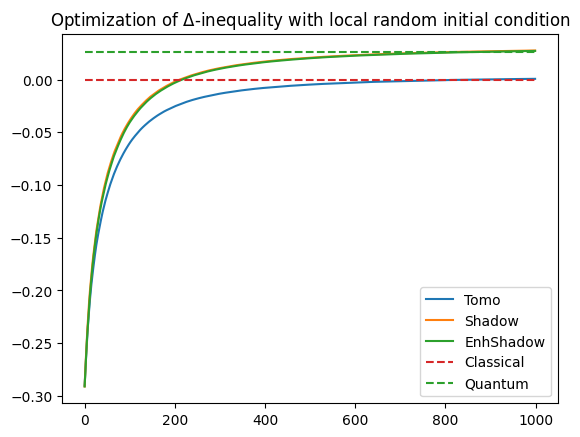

In [ ]:
plt.plot( inequality1_mean )
plt.plot( inequality2_mean )
plt.plot( inequality3_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines((np.sqrt(2)-1)/16 ,0, max_iter, colors='tab:green', linestyles='--')
plt.legend(['Tomo', 'Shadow', 'EnhShadow', 'Classical', 'Quantum' ], loc='lower right' )
plt.title('Optimization of $\Delta$-inequality with local random initial condition')
plt.savefig('inequality_optimization_plot01_07_04_2026.pdf')

<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\jeanc\AppData\Local\Temp\ipykernel_163120\4175701629.py:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title('Optimization of $\Delta$-inequality with local random initial condition')


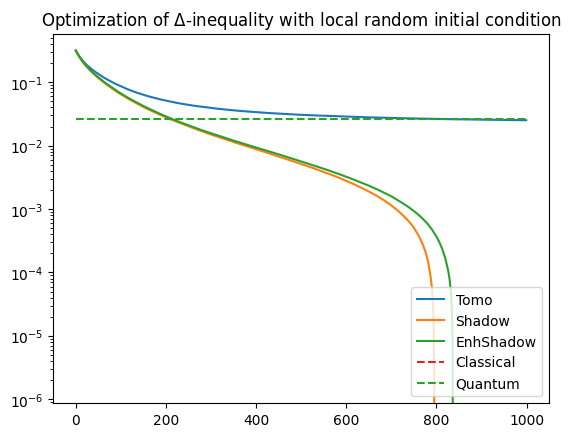

In [ ]:
max_vio = (np.sqrt(2)-1)/16

plt.plot( max_vio-inequality1_mean )
plt.plot( max_vio-inequality2_mean )
plt.plot( max_vio-inequality3_mean )
plt.hlines(0,0,max_iter, colors='tab:red', linestyles='--')
plt.hlines( max_vio, 0, max_iter, colors='tab:green', linestyles='--')
plt.yscale('log')
plt.legend(['Tomo', 'Shadow', 'EnhShadow', 'Classical', 'Quantum' ], loc='lower right' )
plt.title('Optimization of $\Delta$-inequality with local random initial condition')
plt.savefig('inequality_optimization_plot02_07_042026.pdf')